# Redrob Candidate Ranking — EDA v1

First honest look at the data. Streaming only; no full load into memory.

In [1]:
# Cell 1: Imports + integrity check
import datetime
import os
import random
import statistics
import sys
from collections import Counter

import matplotlib.pyplot as plt

# Make src.* importable when notebook runs from notebooks/
sys.path.insert(0, os.path.abspath(".."))

from src.utils.integrity import verify_data_integrity
from src.ingestion.loader import iter_candidates, load_candidates_sample
from src.ingestion.jd import get_jd_text

# Verify staged data before any analysis
verify_data_integrity()
print("[integrity] OK — all challenge files match their SHA-256 fingerprints.")


[integrity] OK — all challenge files match their SHA-256 fingerprints.


## Cell 2: Basic counts
Stream once and compute dataset-level aggregates.

In [2]:
# Cell 2: Basic counts (single streaming pass)
total = 0
skills_per_cand = []
career_per_cand = []
edu_per_cand = []

for c in iter_candidates():
    total += 1
    skills_per_cand.append(len(c.get("skills", [])))
    career_per_cand.append(len(c.get("career_history", [])))
    edu_per_cand.append(len(c.get("education", [])))

print(f"Total candidates:              {total:,}")
print(f"Avg skills per candidate:      {statistics.mean(skills_per_cand):.2f}")
print(f"Avg career entries per cand:   {statistics.mean(career_per_cand):.2f}")
print(f"Avg education entries per cand:{statistics.mean(edu_per_cand):.2f}")


Total candidates:              100,000
Avg skills per candidate:      9.60
Avg career entries per cand:   3.00
Avg education entries per cand:1.40


## Cell 3: Title distribution

Top 30 titles:
  'business analyst'                 5833
  'hr manager'                       5830
  'mechanical engineer'              5791
  'accountant'                       5764
  'project manager'                  5754
  'customer support'                 5750
  'operations manager'               5744
  'content writer'                   5727
  'sales executive'                  5713
  'civil engineer'                   5702
  'graphic designer'                 5689
  'marketing manager'                5524
  'software engineer'                3450
  'full stack developer'             2873
  'cloud engineer'                   2836
  'java developer'                   2809
  '.net developer'                   2788
  'devops engineer'                  2787
  'mobile developer'                 2757
  'frontend engineer'                2738
  'qa engineer'                      2682
  'analytics engineer'                764
  'data engineer'                     744
  'data analyst'   

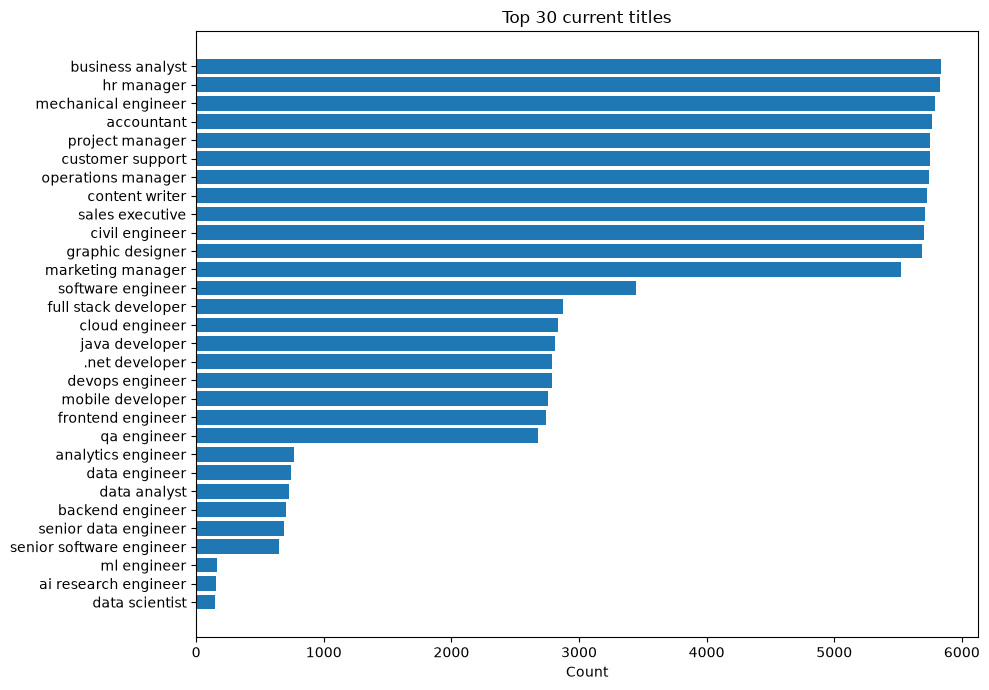

In [3]:
# Cell 3: Top 30 current titles (case-normalized)
title_counter = Counter()
for c in iter_candidates():
    title = c.get("profile", {}).get("current_title", "").strip().lower()
    if title:
        title_counter[title] += 1

top_titles = title_counter.most_common(30)
print("Top 30 titles:")
for title, count in top_titles:
    print(f"  {title!r:32s} {count:6d}")

plt.figure(figsize=(10, 7))
plt.barh([t for t, _ in reversed(top_titles)], [c for _, c in reversed(top_titles)])
plt.xlabel("Count")
plt.title("Top 30 current titles")
plt.tight_layout()
plt.show()


## Cell 4: Skill distribution

Unique skill names: 133
Top 30 skills:
  'html'                            12246
  'databricks'                      12244
  'redux'                           12222
  'terraform'                       12187
  'angular'                         12173
  'figma'                           12157
  'salesforce crm'                  12157
  'vue.js'                          12142
  'sales'                           12138
  'accounting'                      12136
  'agile'                           12135
  'kafka'                           12114
  'excel'                           12109
  'bigquery'                        12108
  'ci/cd'                           12108
  'project management'              12106
  'airflow'                         12105
  'aws'                             12104
  'flask'                           12104
  'scrum'                           12083
  'illustrator'                     12072
  'kubernetes'                      12071
  'etl'                             1

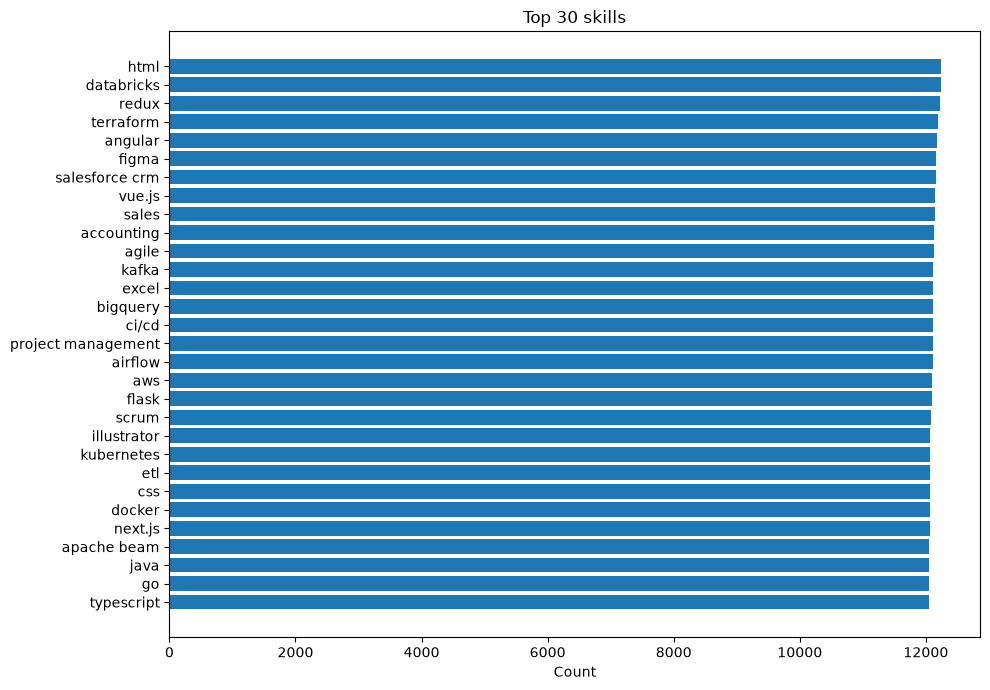

In [4]:
# Cell 4: Top 30 skills across all candidates (flat count)
skill_counter = Counter()
for c in iter_candidates():
    for s in c.get("skills", []):
        name = s.get("name", "").strip().lower()
        if name:
            skill_counter[name] += 1

top_skills = skill_counter.most_common(30)
print(f"Unique skill names: {len(skill_counter)}")
print("Top 30 skills:")
for skill, count in top_skills:
    print(f"  {skill!r:32s} {count:6d}")

plt.figure(figsize=(10, 7))
plt.barh([s for s, _ in reversed(top_skills)], [c for _, c in reversed(top_skills)])
plt.xlabel("Count")
plt.title("Top 30 skills")
plt.tight_layout()
plt.show()


## Cell 5: Company distribution

Top 30 companies:
  'infosys'                          7590
  'wayne enterprises'                7571
  'wipro'                            7566
  'initech'                          7528
  'pied piper'                       7500
  'globex inc'                       7492
  'acme corp'                        7490
  'dunder mifflin'                   7467
  'tcs'                              7451
  'hooli'                            7378
  'stark industries'                 7323
  'swiggy'                           1288
  'accenture'                        1274
  'capgemini'                        1265
  'cred'                             1257
  'hcl'                              1250
  'razorpay'                         1246
  'zomato'                           1226
  'mindtree'                         1225
  'cognizant'                        1213
  'flipkart'                         1171
  'tech mahindra'                    1168
  'mphasis'                          1153
  'meesho'      

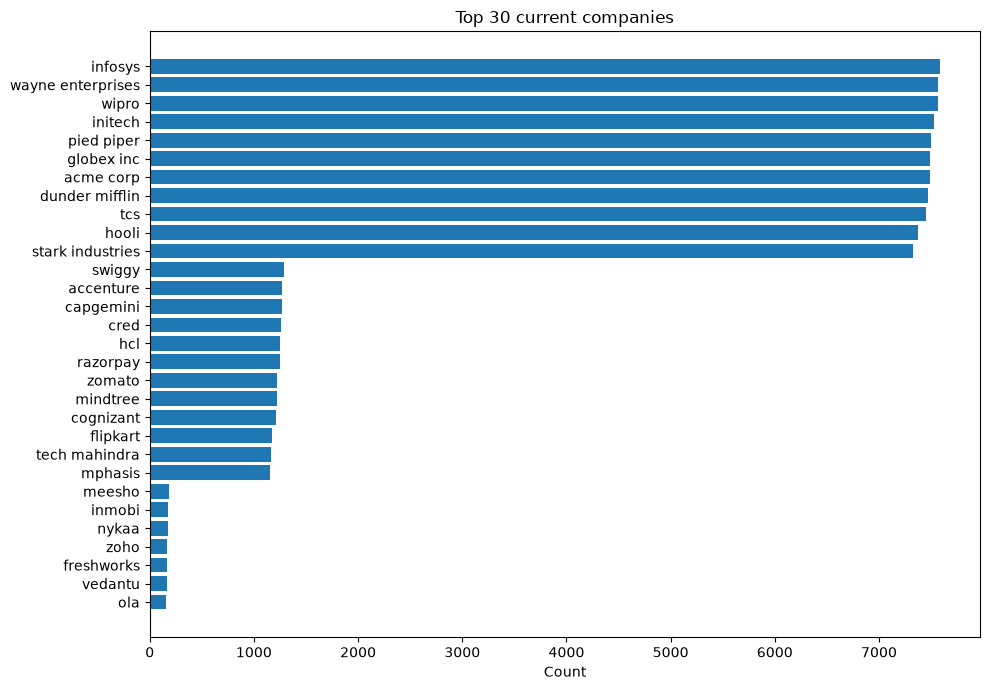

In [5]:
# Cell 5: Top 30 current companies (case-normalized)
company_counter = Counter()
for c in iter_candidates():
    company = c.get("profile", {}).get("current_company", "").strip().lower()
    if company:
        company_counter[company] += 1

top_companies = company_counter.most_common(30)
print("Top 30 companies:")
for company, count in top_companies:
    print(f"  {company!r:32s} {count:6d}")

plt.figure(figsize=(10, 7))
plt.barh([co for co, _ in reversed(top_companies)], [c for _, c in reversed(top_companies)])
plt.xlabel("Count")
plt.title("Top 30 current companies")
plt.tight_layout()
plt.show()


## Cell 6: Location distribution

In [6]:
# Cell 6: Top 20 locations and country distribution
location_counter = Counter()
country_counter = Counter()
for c in iter_candidates():
    prof = c.get("profile", {})
    loc = prof.get("location", "").strip()
    country = prof.get("country", "").strip()
    if loc:
        location_counter[loc] += 1
    if country:
        country_counter[country] += 1

print("Top 20 locations:")
for loc, count in location_counter.most_common(20):
    print(f"  {loc!r:40s} {count:6d}")
print()
print("Country distribution:")
for country, count in country_counter.most_common(10):
    print(f"  {country!r:20s} {count:6d} ({count/total*100:.1f}%)")


Top 20 locations:
  'Bhubaneswar, Odisha'                      4321
  'Noida, Uttar Pradesh'                     4283
  'Hyderabad, Telangana'                     4283
  'Jaipur, Rajasthan'                        4268
  'Bangalore, Karnataka'                     4238
  'Kolkata, West Bengal'                     4230
  'Indore, Madhya Pradesh'                   4198
  'Pune, Maharashtra'                        4186
  'Chennai, Tamil Nadu'                      4164
  'Delhi, Delhi'                             4161
  'Trivandrum, Kerala'                       4151
  'Ahmedabad, Gujarat'                       4143
  'Chandigarh, Chandigarh'                   4128
  'Coimbatore, Tamil Nadu'                   4113
  'Vizag, Andhra Pradesh'                    4093
  'Kochi, Kerala'                            4073
  'Mumbai, Maharashtra'                      4043
  'Gurgaon, Haryana'                         4037
  'Sydney'                                   2579
  'San Francisco'               

## Cell 7: Experience-year distribution

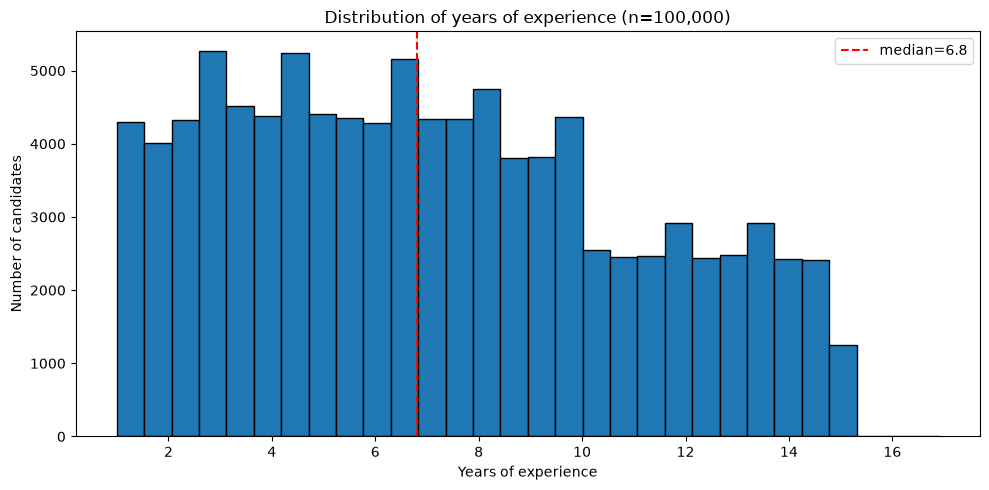

Median YoE: 6.8
Mean YoE:   7.2
% in 5-9 band: 34.4%


In [7]:
# Cell 7: Histogram of years_of_experience
yoes = []
for c in iter_candidates():
    yoe = c.get("profile", {}).get("years_of_experience")
    if yoe is not None:
        yoes.append(yoe)

plt.figure(figsize=(10, 5))
plt.hist(yoes, bins=30, edgecolor="black")
plt.xlabel("Years of experience")
plt.ylabel("Number of candidates")
plt.title(f"Distribution of years of experience (n={len(yoes):,})")
plt.axvline(statistics.median(yoes), color="red", linestyle="--", label=f"median={statistics.median(yoes):.1f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Median YoE: {statistics.median(yoes):.1f}")
print(f"Mean YoE:   {statistics.mean(yoes):.1f}")
print(f"% in 5-9 band: {sum(1 for y in yoes if 5 <= y <= 9) / len(yoes) * 100:.1f}%")


## Cell 8: redrob_signals distribution

In [8]:
# Cell 8: Median and IQR of key behavioral signals
rr_rates = []
notice_days = []
github_scores = []
profile_scores = []
interview_rates = []

for c in iter_candidates():
    sig = c.get("redrob_signals", {})
    rr_rates.append(sig.get("recruiter_response_rate", 0))
    notice_days.append(sig.get("notice_period_days", 0))
    github_scores.append(sig.get("github_activity_score", 0))
    profile_scores.append(sig.get("profile_completeness_score", 0))
    interview_rates.append(sig.get("interview_completion_rate", 0))

def iqr(data):
    s = sorted(data)
    n = len(s)
    return s[n // 4], s[3 * n // 4]

signals = {
    "recruiter_response_rate": rr_rates,
    "notice_period_days": notice_days,
    "github_activity_score": github_scores,
    "profile_completeness_score": profile_scores,
    "interview_completion_rate": interview_rates,
}

for name, data in signals.items():
    print(f"{name:30s} median={statistics.median(data):.2f}  IQR={iqr(data)}")


recruiter_response_rate        median=0.44  IQR=(0.25, 0.62)
notice_period_days             median=90.00  IQR=(60, 120)
github_activity_score          median=-1.00  IQR=(-1, 16.7)
profile_completeness_score     median=56.80  IQR=(42.2, 71.6)
interview_completion_rate      median=0.62  IQR=(0.48, 0.76)


## Cell 9: Recency distribution

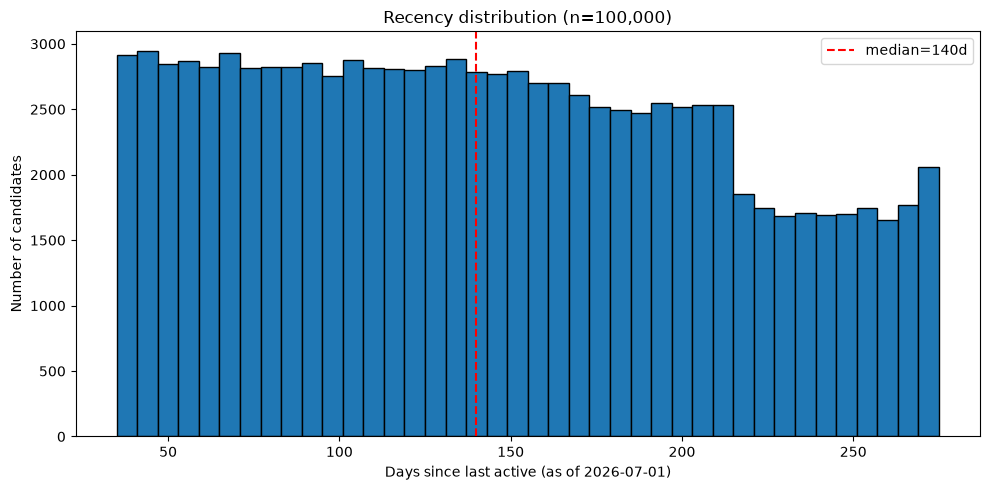

Median days since last active: 140
Active within 30d: 0.0%
Active within 90d: 26.7%


In [9]:
# Cell 9: Days since last_active_date relative to 2026-07-01
REFERENCE = datetime.date(2026, 7, 1)
recency_days = []

for c in iter_candidates():
    lad = c.get("redrob_signals", {}).get("last_active_date")
    if lad:
        d = datetime.date.fromisoformat(lad)
        recency_days.append((REFERENCE - d).days)

plt.figure(figsize=(10, 5))
plt.hist(recency_days, bins=40, edgecolor="black")
plt.xlabel("Days since last active (as of 2026-07-01)")
plt.ylabel("Number of candidates")
plt.title(f"Recency distribution (n={len(recency_days):,})")
plt.axvline(statistics.median(recency_days), color="red", linestyle="--", label=f"median={statistics.median(recency_days):.0f}d")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Median days since last active: {statistics.median(recency_days):.0f}")
print(f"Active within 30d: {sum(1 for d in recency_days if d <= 30) / len(recency_days) * 100:.1f}%")
print(f"Active within 90d: {sum(1 for d in recency_days if d <= 90) / len(recency_days) * 100:.1f}%")


## Cell 10: Manual read — 15 candidate summaries

In [10]:
# Cell 10: Pretty summaries of 15 candidates
# 8 fixed indices + 7 with strong ML/AI/Data titles
ML_TITLES = [
    "ml engineer", "ai research engineer", "data scientist", "senior data engineer",
    "data engineer", "backend engineer", "analytics engineer",
]

ml_candidates = []
fixed_indices = {0, 100, 1000, 5000, 25000, 50000, 75000, 99000}
selected = {}

for i, c in enumerate(iter_candidates()):
    if i in fixed_indices:
        selected[i] = c
    title = c.get("profile", {}).get("current_title", "").strip().lower()
    if title in ML_TITLES and len(ml_candidates) < 7:
        ml_candidates.append((i, c))
    if len(selected) == len(fixed_indices) and len(ml_candidates) == 7:
        break

for idx, c in ml_candidates:
    selected[idx] = c

def summarize(c):
    prof = c.get("profile", {})
    skills = c.get("skills", [])
    top5 = [s.get("name", "?") for s in skills[:5]]
    career = c.get("career_history", [])
    first_job = career[0] if career else {}
    sig = c.get("redrob_signals", {})
    return {
        "id": c.get("candidate_id"),
        "title": prof.get("current_title"),
        "company": prof.get("current_company"),
        "yoe": prof.get("years_of_experience"),
        "location": f"{prof.get('location')}, {prof.get('country')}",
        "top5_skills": top5,
        "first_job": f"{first_job.get('title')} @ {first_job.get('company')} ({first_job.get('duration_months')}mo)",
        "notice": sig.get("notice_period_days"),
        "response_rate": sig.get("recruiter_response_rate"),
        "profile_score": sig.get("profile_completeness_score"),
    }

for idx in sorted(selected):
    s = summarize(selected[idx])
    print(f"--- idx {idx} | {s['id']} ---")
    print(f"  Title: {s['title']} @ {s['company']} | YoE: {s['yoe']} | {s['location']}")
    print(f"  Top skills: {', '.join(s['top5_skills'])}")
    print(f"  First career entry: {s['first_job']}")
    print(f"  Signals: notice={s['notice']}d, response_rate={s['response_rate']}, profile_score={s['profile_score']}")
    print()


--- idx 0 | CAND_0000001 ---
  Title: Backend Engineer @ Mindtree | YoE: 6.9 | Toronto, Canada
  Top skills: Tailwind, NLP, Image Classification, Fine-tuning LLMs, Weights & Biases
  First career entry: Backend Engineer @ Mindtree (27mo)
  Signals: notice=60d, response_rate=0.34, profile_score=86.9

--- idx 9 | CAND_0000010 ---
  Title: Data Engineer @ Ola | YoE: 4.6 | London, UK
  Top skills: GCP, Spring Boot, Kubeflow, Java, GANs
  First career entry: Data Engineer @ Ola (55mo)
  Signals: notice=120d, response_rate=0.4, profile_score=81.6

--- idx 100 | CAND_0000101 ---
  Title: Customer Support @ Globex Inc | YoE: 7.0 | Kolkata, West Bengal, India
  Top skills: Project Management, GraphQL, TypeScript, GCP, Docker
  First career entry: Customer Support @ Globex Inc (39mo)
  Signals: notice=120d, response_rate=0.46, profile_score=33.2

--- idx 189 | CAND_0000190 ---
  Title: Backend Engineer @ Paytm | YoE: 3.7 | Kochi, Kerala, India
  Top skills: Feature Engineering, CNN, Photoshop, Q

## Cell 11: Honeypot hunt on 15 sampled candidates

In [11]:
# Cell 11: Honeypot checks on the 15 candidates above
from typing import List, Dict, Any

sample: List[Dict[str, Any]] = list(selected.values())

CONSULTING_KEYWORDS = ["accenture", "tcs", "infosys", "cognizant", "wipro", "capgemini",
                       "deloitte", "ey", "pwc", "kpmg", "ibm", "tech mahindra", "hcl", "mphasis"]

flags = []
for c in sample:
    prof = c.get("profile", {})
    yoe = prof.get("years_of_experience", 0)
    career = c.get("career_history", [])
    total_tenure_months = sum(job.get("duration_months", 0) or 0 for job in career)
    implied_yoe = total_tenure_months / 12.0
    ratio = yoe / implied_yoe if implied_yoe > 0 else float("inf")

    skills = c.get("skills", [])
    expert_zero_duration = sum(
        1 for s in skills
        if s.get("proficiency", "").lower() == "expert" and (s.get("duration_months") == 0 or s.get("duration_months") is None)
    )
    expert_zero_endorsements = sum(
        1 for s in skills
        if s.get("proficiency", "").lower() == "expert" and (s.get("endorsements", 0) or 0) == 0
    )

    descriptions = [job.get("description", "").strip() for job in career if job.get("description")]
    identical_descriptions = len(descriptions) != len(set(descriptions))

    long_tenure = any((job.get("duration_months", 0) or 0) > 240 for job in career)

    company = prof.get("current_company", "").lower()
    consulting_firm = any(k in company for k in CONSULTING_KEYWORDS)

    sig = c.get("redrob_signals", {})
    profile_score = sig.get("profile_completeness_score", 0)
    suspiciously_complete = profile_score >= 99.0 and yoe <= 1.0

    if ratio > 2:
        flags.append(f"{c['candidate_id']}: timeline_inflation (ratio={ratio:.1f})")
    if expert_zero_duration >= 3:
        flags.append(f"{c['candidate_id']}: expert_zero_duration (count={expert_zero_duration})")
    if expert_zero_endorsements >= 3:
        flags.append(f"{c['candidate_id']}: expert_zero_endorsements (count={expert_zero_endorsements})")
    if identical_descriptions:
        flags.append(f"{c['candidate_id']}: identical_career_descriptions")
    if long_tenure:
        flags.append(f"{c['candidate_id']}: tenure_over_240_months")
    if consulting_firm:
        flags.append(f"{c['candidate_id']}: consulting_firm ({company})")
    if suspiciously_complete:
        flags.append(f"{c['candidate_id']}: rookie_perfect_profile")

print(f"Honeypot flags found in {len(sample)} sampled candidates:")
if flags:
    for f in flags:
        print(f"  - {f}")
else:
    print("  None detected in this sample.")


Honeypot flags found in 14 sampled candidates:
  - CAND_0001001: consulting_firm (wipro)
  - CAND_0005001: consulting_firm (infosys)
  - CAND_0025001: identical_career_descriptions
  - CAND_0050001: identical_career_descriptions
  - CAND_0075001: identical_career_descriptions
  - CAND_0000210: identical_career_descriptions
